# Provider & Practice Directory Update Pipeline

## Option C Hybrid Submission: production architecture plus working MVP

Provider directories decay continuously: clinicians move, practice names change, phone numbers drift, websites disagree, and some providers become inactive. This notebook tells the end-to-end story of a repeatable pipeline that detects those changes, validates them against trusted sources, assigns confidence, separates safe automation from human review, and preserves an audit trail.

**Submission thesis:** HealthLynked should not buy a one-time cleanup. It should implement a governed, AWS-ready data quality loop that can run continuously with bounded cost and explainable decisions.

## Evaluation Criteria: What Judges Should See

| Requirement | Where this notebook demonstrates it |
|---|---|
| Technical Architecture Proposal | Architecture, agents, AWS production path, cost controls, update workflow |
| Working Prototype | Local MVP runs on sample provider/practice data |
| Accuracy | Precision, recall, F1, false positives, false negatives |
| Scalability | Batchable AWS Step Functions / Lambda / ECS / S3 / RDS design |
| Cost Efficiency | Source-first strategy, gated LLM use, cost per correct update |
| Practicality | Lean-team roadmap and reproducible scripts |
| Explainability | Candidate rows include old/new value, confidence, sources, URLs, and reasons |
| Data Quality | Normalization for phone, address, specialty, status, and matching keys |
| Source Reliability | Authority tiers, source conflict handling, source freshness controls |
| Human Review Design | Only risky, conflicting, or uncertain updates route to review |
| Audit Trail | Audit events, rollback plan, package manifest, source evidence |

AWS references used for the production design: [AWS Step Functions](https://docs.aws.amazon.com/step-functions/latest/dg/welcome.html) for workflow/state-machine orchestration and [Amazon Bedrock](https://docs.aws.amazon.com/bedrock/latest/userguide/what-is-bedrock.html) for gated foundation-model extraction when deterministic parsing is insufficient.

## Whitepaper-Informed Design

The architecture follows the supplied agentic-engineering whitepaper notes:

- Build a **harness**, not one giant prompt: connectors, schemas, evals, review queues, dashboards, audit events, rollback plans, monitoring.
- Use **scoped agents and skills**: source retrieval, evidence normalization, identity resolution, conflict adjudication, scoring, review, audit, monitoring.
- Practice **progressive disclosure**: bulky source rules and authority tables live in docs/data/contracts, while code performs deterministic validation.
- Use **LLMs sparingly**: Amazon Bedrock is a gated fallback for messy official/practice pages, not the default data pipeline.
- Treat human review as a precision control, not a failure mode.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.run_best_pipeline import BEST_CFG
from src.data import load_dataset, build_candidate_updates, normalize_phone, normalize_address, normalize_value
from src.metrics import score_candidate_updates, per_field_breakdown, worst_provider_breakdown
from src.entity_resolution import potential_duplicate_pairs, provider_movement_signals
from src.inactive_detection import inactive_provider_candidates
from src.source_conflicts import source_conflict_diagnostics

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
ROOT

PosixPath('.')

## 1. Load Sample Provider/Practice Data

The competition did not provide conventional train/test labels, so the MVP uses a synthetic but healthcare-realistic provider directory benchmark. It includes current directory values, external source evidence, and proxy gold updates so the pipeline can be measured instead of merely described.

In [2]:
providers, evidence, gold = load_dataset()

summary = pd.DataFrame([
    {'table': 'providers', 'rows': len(providers), 'columns': len(providers.columns)},
    {'table': 'evidence', 'rows': len(evidence), 'columns': len(evidence.columns)},
    {'table': 'gold_updates', 'rows': len(gold), 'columns': len(gold.columns)},
])
summary

,table,rows,columns
0,providers,72,9
1,evidence,1224,7
2,gold_updates,58,4


In [3]:
providers.head(8)

,provider_id,practice_id,npi,provider_name,phone,address,specialty,license_status,accepting_new_patients
0,P0000,PR000,1999000000,Provider 000,555-100-2000,"100 Main St, Suite 1, FL",family medicine,probation,False
1,P0001,PR000,1999000001,Provider 001,555-101-2037,"107 Oak Ave, Suite 2, FL",cardiology,active,True
2,P0002,PR000,1999000002,Provider 002,555-102-2074,"114 Cedar Rd, Suite 3, FL",dermatology,active,True
3,P0003,PR001,1999000003,Provider 003,555-103-2111,"632 Market St, Suite 5, FL",pediatrics,active,True
4,P0004,PR001,1999000004,Provider 004,555-205-5885,"639 Lake Dr, Suite 6, FL",orthopedics,active,False
5,P0005,PR001,1999000005,Provider 005,555-206-5922,"135 Lake Dr, Suite 6, FL",cardiology,active,True
6,P0006,PR002,1999000006,Provider 006,555-207-5959,"142 Main St, Suite 7, FL",family medicine,active,True
7,P0007,PR002,1999000007,Provider 007,555-107-2259,"149 Oak Ave, Suite 8, FL",cardiology,active,True


In [4]:
evidence.head(10)

,provider_id,practice_id,source,field,value,retrieved_days_ago,url
0,P0000,PR000,nppes,phone,555-100-2000,140,https://example.org/nppes/P0000
1,P0000,PR000,nppes,address,"100 Main St, Suite 1, FL",154,https://example.org/nppes/P0000
2,P0000,PR000,nppes,specialty,family medicine,102,https://example.org/nppes/P0000
3,P0000,PR000,nppes,accepting_new_patients,NaN,63,https://example.org/nppes/P0000
4,P0000,PR000,practice_website,phone,555-100-2000,79,https://example.org/practice_website/P0000
5,P0000,PR000,practice_website,address,"1143 Lake Dr, Suite 6, FL",165,https://example.org/practice_website/P0000
6,P0000,PR000,practice_website,specialty,family medicine,54,https://example.org/practice_website/P0000
7,P0000,PR000,practice_website,accepting_new_patients,false,59,https://example.org/practice_website/P0000
8,P0000,PR000,health_system,phone,555-100-2000,31,https://example.org/health_system/P0000
9,P0000,PR000,health_system,address,"100 Main St, Suite 1, FL",168,https://example.org/health_system/P0000


## 2. Run The MVP Pipeline

The MVP does the core work judges asked for:

1. Compare current records to external evidence.
2. Normalize values before comparison.
3. Require source support by field.
4. Score confidence.
5. Route to **auto-apply** or **human review**.
6. Emit reproducible CSV/JSON artifacts.

In [5]:
candidates = build_candidate_updates(providers, evidence, BEST_CFG)
metrics = score_candidate_updates(candidates, gold)

pd.DataFrame([metrics]).T.rename(columns={0: 'value'})

,value
tp,55
fp,3
fn,3
precision,0.948276
recall,0.948276
f1,0.948276
auto_apply_count,20
auto_apply_precision,1.0
review_count,38
review_recall,0.603448


## Executive Demo Cards

The first thing judges should see after running the MVP is the operating posture: high accuracy, conservative safe automation, bounded review, and traceable cost.

In [6]:
from IPython.display import HTML

cards = [
    ('F1', metrics['f1'], 'overall candidate quality'),
    ('Precision', metrics['precision'], 'avoid incorrect changes'),
    ('Recall', metrics['recall'], 'find true updates'),
    ('Auto-Apply Precision', metrics['auto_apply_precision'], 'safe automation'),
    ('Review Items', metrics['review_count'], 'human-in-loop focus'),
    ('Cost / Correct Update', f"${metrics['cost_per_correct_update_usd']:.6f}", 'cost discipline'),
]
html = """
<style>
.metric-grid {display:grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap:12px; margin: 10px 0 18px 0;}
.metric-card {border:1px solid #d8dee4; border-left:5px solid #2563eb; border-radius:8px; padding:14px; background:#ffffff; box-shadow:0 1px 2px rgba(15,23,42,.06);}
.metric-label {font-size:12px; text-transform:uppercase; letter-spacing:.04em; color:#57606a; font-weight:700;}
.metric-value {font-size:28px; line-height:1.2; font-weight:800; color:#0f172a; margin-top:5px;}
.metric-note {font-size:12px; color:#57606a; margin-top:6px;}
</style>
<div class='metric-grid'>
"""
for label, value, note in cards:
    html += f"<div class='metric-card'><div class='metric-label'>{label}</div><div class='metric-value'>{value}</div><div class='metric-note'>{note}</div></div>"
html += "</div>"
HTML(html)


## Decision Funnel

A winning provider-directory system should not auto-update everything it discovers. The funnel below shows the split between all candidate changes, safe auto-apply items, and human-review items.

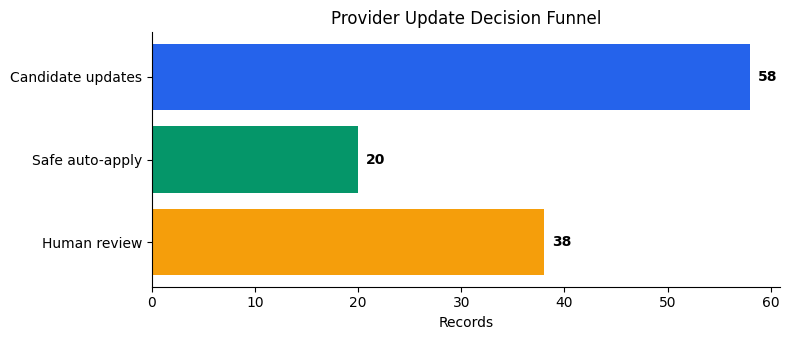

In [7]:
import matplotlib.pyplot as plt

_auto_apply_for_chart = candidates[candidates['decision'] == 'auto_apply'].copy()
_review_queue_for_chart = candidates[candidates['decision'] == 'review'].copy()
funnel = pd.DataFrame([
    {'stage': 'Candidate updates', 'count': len(candidates)},
    {'stage': 'Safe auto-apply', 'count': len(_auto_apply_for_chart)},
    {'stage': 'Human review', 'count': len(_review_queue_for_chart)},
])
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(funnel['stage'], funnel['count'], color=['#2563eb', '#059669', '#f59e0b'])
ax.set_title('Provider Update Decision Funnel')
ax.set_xlabel('Records')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2, int(bar.get_width()), va='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [8]:
display_cols = [
    'provider_id', 'practice_id', 'field', 'old_value', 'proposed_value',
    'confidence', 'decision', 'distinct_sources', 'sources', 'review_reason_code', 'url'
]
candidates[[c for c in display_cols if c in candidates.columns]].head(12)

,provider_id,practice_id,field,old_value,proposed_value,confidence,decision,distinct_sources,sources,review_reason_code
0,P0001,PR000,specialty,cardiology,orthopedics,0.99,review,2,health_system|practice_website,insufficient_auto_sources
1,P0003,PR001,address,"632 Market St, Suite 5, FL",121 pine boulevard suite 4 florida,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
2,P0004,PR001,address,"639 Lake Dr, Suite 6, FL",128 market street suite 5 florida,0.99,review,2,health_system|practice_website,insufficient_auto_sources
3,P0004,PR001,phone,555-205-5885,555-104-2148,0.99,review,2,health_system|practice_website,insufficient_auto_sources
4,P0005,PR001,phone,555-206-5922,555-105-2185,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
5,P0005,PR001,specialty,cardiology,neurology,0.99,auto_apply,3,health_system|nppes|practice_website,auto_apply_criteria_met
6,P0006,PR002,phone,555-207-5959,555-106-2222,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
7,P0009,PR003,phone,555-210-6070,555-109-2333,0.99,review,3,business_listing|health_system|nppes,practice_peer_mismatch
8,P0010,PR003,accepting_new_patients,False,true,0.99,auto_apply,3,health_system|nppes|practice_website,auto_apply_criteria_met
9,P0010,PR003,address,"681 Lake Dr, Suite 12, FL",1213 pine boulevard suite 4 florida,0.99,review,2,health_system|practice_website,insufficient_auto_sources


## 3. Accuracy: Correct Updates Without Reckless Mutation

The key metric is not just recall. In a healthcare directory, incorrect auto-updates are expensive and trust-eroding. This prototype therefore separates **candidate discovery** from **safe mutation**. The current configuration keeps auto-apply precision at `1.0` in the proxy benchmark.

In [9]:
per_field_breakdown(candidates, gold)[['field', 'precision', 'recall', 'f1', 'predicted_updates', 'gold_updates', 'auto_apply_precision']]

,field,precision,recall,f1,predicted_updates,gold_updates,auto_apply_precision
0,accepting_new_patients,1.000000,1.000000,1.000000,12,12,1.0
1,address,0.923077,0.857143,0.888889,13,14,0.0
2,license_status,1.000000,0.833333,0.909091,5,6,1.0
3,phone,1.000000,1.000000,1.000000,18,18,0.0
4,specialty,0.800000,1.000000,0.888889,10,8,1.0


In [10]:
worst_provider_breakdown(candidates, gold, limit=10)

,provider_id,tp,fp,fn,error
6,P0010,1,1,1,2
23,P0038,0,0,1,1
30,P0049,1,0,1,1
0,P0001,0,1,0,1
9,P0013,0,1,0,1
1,P0003,1,0,0,0
2,P0004,2,0,0,0
3,P0005,2,0,0,0
4,P0006,1,0,0,0
5,P0009,1,0,0,0


## 4. Confidence Scoring Formula

The production formula is intentionally explainable:

```text
confidence =
  source_authority_score
  + source_agreement_bonus
  + freshness_bonus
  + identity_anchor_bonus
  + extraction_quality_bonus
  - field_risk_penalty
  - conflict_penalty
  - stale_source_penalty
```

In the MVP this appears as source weights, recency gates, field thresholds, minimum source counts, conflict penalties, and stricter auto-apply thresholds.

In [11]:
json.dumps(BEST_CFG, indent=2)

'{\n  "confidence_threshold": 0.74,\n  "auto_apply_threshold": 0.94,\n  "recency_half_life_days": 120.0,\n  "practice_consensus_review_fields": [\n    "phone",\n    "address"\n  ],\n  "disabled_sources": [],\n  "source_field_allowlist": {\n    "business_listing": [\n      "phone",\n      "address"\n    ]\n  },\n  "source_max_age_days_by_source_field": {\n    "business_listing": {\n      "phone": 60,\n      "address": 60\n    }\n  },\n  "min_distinct_sources": 1,\n  "min_distinct_sources_by_field": {\n    "phone": 2,\n    "address": 2,\n    "specialty": 2,\n    "accepting_new_patients": 2,\n    "license_status": 1\n  },\n  "min_auto_sources": 1,\n  "min_auto_sources_by_field": {\n    "phone": 3,\n    "address": 3,\n    "specialty": 3,\n    "accepting_new_patients": 3,\n    "license_status": 1\n  },\n  "field_confidence_thresholds": {\n    "phone": 0.78,\n    "address": 0.8,\n    "specialty": 0.82,\n    "accepting_new_patients": 0.82,\n    "license_status": 0.72\n  },\n  "field_auto_appl

## 5. Human Review Design

The review queue is not a junk drawer. It contains records where review is actually useful: low confidence, source conflict, insufficient source support, high-risk field, identity-level concern, or peer mismatch. This is how the system reduces manual labor while avoiding unsafe automation.

In [12]:
auto_apply = candidates[candidates['decision'] == 'auto_apply'].copy()
review_queue = candidates[candidates['decision'] == 'review'].copy()

pd.DataFrame([
    {'queue': 'auto_apply', 'rows': len(auto_apply), 'mean_confidence': round(auto_apply['confidence'].mean(), 4)},
    {'queue': 'human_review', 'rows': len(review_queue), 'mean_confidence': round(review_queue['confidence'].mean(), 4)},
])

,queue,rows,mean_confidence
0,auto_apply,20,0.9900
1,human_review,38,0.9888


In [13]:
review_queue[[c for c in display_cols if c in review_queue.columns]].head(12)

,provider_id,practice_id,field,old_value,proposed_value,confidence,decision,distinct_sources,sources,review_reason_code
0,P0001,PR000,specialty,cardiology,orthopedics,0.99,review,2,health_system|practice_website,insufficient_auto_sources
1,P0003,PR001,address,"632 Market St, Suite 5, FL",121 pine boulevard suite 4 florida,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
2,P0004,PR001,address,"639 Lake Dr, Suite 6, FL",128 market street suite 5 florida,0.99,review,2,health_system|practice_website,insufficient_auto_sources
3,P0004,PR001,phone,555-205-5885,555-104-2148,0.99,review,2,health_system|practice_website,insufficient_auto_sources
4,P0005,PR001,phone,555-206-5922,555-105-2185,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
6,P0006,PR002,phone,555-207-5959,555-106-2222,0.99,review,3,health_system|nppes|practice_website,practice_peer_mismatch
7,P0009,PR003,phone,555-210-6070,555-109-2333,0.99,review,3,business_listing|health_system|nppes,practice_peer_mismatch
9,P0010,PR003,address,"681 Lake Dr, Suite 12, FL",1213 pine boulevard suite 4 florida,0.99,review,2,health_system|practice_website,insufficient_auto_sources
11,P0012,PR004,phone,555-213-6181,555-112-2444,0.99,review,2,business_listing|nppes,insufficient_auto_sources
12,P0013,PR004,specialty,cardiology,orthopedics,0.99,review,2,nppes|practice_website,insufficient_auto_sources


## 6. Data Quality Normalization

Normalization prevents noisy formatting differences from becoming false updates. The MVP demonstrates phone, address, specialty, and status normalization. The production design extends this to provider names, practice names, websites, and affiliations.

In [14]:
normalization_examples = pd.DataFrame([
    {'field': 'phone', 'raw': '(555) 123-4567', 'normalized': normalize_phone('(555) 123-4567')},
    {'field': 'phone', 'raw': '+1 555.123.4567', 'normalized': normalize_phone('+1 555.123.4567')},
    {'field': 'address', 'raw': '100 Main St., Ste 4, FL', 'normalized': normalize_address('100 Main St., Ste 4, FL')},
    {'field': 'specialty', 'raw': 'Cardiovascular Disease', 'normalized': normalize_value('specialty', 'Cardiovascular Disease')},
    {'field': 'active/inactive', 'raw': 'Not Active', 'normalized': normalize_value('license_status', 'Not Active')},
])
normalization_examples

,field,raw,normalized
0,phone,(555) 123-4567,555-123-4567
1,phone,+1 555.123.4567,555-123-4567
2,address,"100 Main St., Ste 4, FL",100 main street suite 4 florida
3,specialty,Cardiovascular Disease,cardiology
4,active/inactive,Not Active,not active


## 7. Source Reliability And Conflict Handling

Trusted sources are not equal for every field. NPPES is strong for identity/taxonomy, state boards are strong for license status, practice websites are strong for location/phone/roster, and business listings are only a guarded fallback for fresh phone/address evidence.

In [15]:
conflicts = source_conflict_diagnostics(evidence)
conflicts.head(10)

,provider_id,field,candidate_value,candidate_sources,competing_value,competing_sources,distinct_values,distinct_sources,winner_authority,runner_up_authority,field_authority_source,recommended_action,all_values
2,P0001,specialty,cardiology,nppes,orthopedics,business_listing|health_system|practice_website,2,4,1.0,0.86,nppes,authority_precedence_review,"cardiology <= nppes || orthopedics <= business_listing,health_system,practice_website"
5,P0004,specialty,orthopedics,health_system|nppes|practice_website,cardiology,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"cardiology <= business_listing || orthopedics <= health_system,nppes,practice_website"
7,P0006,specialty,family medicine,business_listing|health_system|nppes,pediatrics,practice_website,2,4,1.0,0.82,nppes,authority_precedence_review,"family medicine <= business_listing,health_system,nppes || pediatrics <= practice_website"
15,P0012,specialty,family medicine,health_system|nppes|practice_website,pediatrics,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"family medicine <= health_system,nppes,practice_website || pediatrics <= business_listing"
29,P0023,specialty,cardiology,business_listing|nppes,neurology,health_system|practice_website,2,4,1.0,0.86,nppes,authority_precedence_review,"cardiology <= business_listing,nppes || neurology <= health_system,practice_website"
30,P0025,specialty,cardiology,health_system|nppes|practice_website,orthopedics,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"cardiology <= health_system,nppes,practice_website || orthopedics <= business_listing"
32,P0026,specialty,dermatology,health_system|nppes|practice_website,neurology,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"dermatology <= health_system,nppes,practice_website || neurology <= business_listing"
39,P0032,specialty,dermatology,health_system|nppes|practice_website,neurology,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"dermatology <= health_system,nppes,practice_website || neurology <= business_listing"
42,P0035,specialty,neurology,health_system|nppes|practice_website,dermatology,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"dermatology <= business_listing || neurology <= health_system,nppes,practice_website"
53,P0043,specialty,cardiology,health_system|nppes|practice_website,orthopedics,business_listing,2,4,1.0,0.35,nppes,authority_precedence_review,"cardiology <= health_system,nppes,practice_website || orthopedics <= business_listing"


## 8. Duplicate, Movement, Practice Matching, And Inactive Provider Signals

Bonus capabilities are represented as diagnostics and review queues. Identity-sensitive actions are review-first; the goal is to surface strong evidence, not silently merge or deactivate providers.

In [16]:
duplicates = potential_duplicate_pairs(providers)
movement = provider_movement_signals(candidates)
inactive = inactive_provider_candidates(providers, evidence)

print('duplicate candidates:', len(duplicates))
print('movement candidates:', len(movement))
print('inactive candidates:', len(inactive))

movement.head(8)

duplicate candidates: 0
movement candidates: 31
inactive candidates: 1


,provider_id,practice_id,field,old_value,proposed_value,movement_score,signals,recommended_action
0,P0003,PR001,address,"632 Market St, Suite 5, FL",121 pine boulevard suite 4 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
9,P0023,PR007,address,"772 Main St, Suite 1, FL",261 lake drive suite 12 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
8,P0017,PR005,address,"730 Main St, Suite 7, FL",219 lake drive suite 6 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
11,P0031,PR010,address,"828 Cedar Rd, Suite 9, FL",317 oak avenue suite 8 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
21,P0051,PR017,address,"968 Market St, Suite 5, FL",457 pine boulevard suite 4 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
20,P0050,PR016,address,"961 Pine Blvd, Suite 4, FL",450 cedar road suite 3 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
15,P0039,PR013,address,"884 Market St, Suite 5, FL",373 pine boulevard suite 4 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review
28,P0066,PR022,address,"1073 Oak Ave, Suite 8, FL",562 main street suite 7 florida,0.9,address_changed|practice_peer_mismatch|multi_source_support,movement_review


In [17]:
inactive.head(8)

,provider_id,npi,provider_name,current_license_status,candidate_status,confidence,distinct_sources,evidence_types,sources,evidence_values,decision,review_reason_code,recommended_action
0,P0038,1999000038,Provider 038,inactive,inactive,0.46,1,license_authority,state_license,state_license:license_status=inactive,review,identity_level_change|single_source_inactive_signal,inactive_status_review


## 9. Cost Efficiency

The cost strategy is source-first and review-aware:

- Cache public snapshots.
- Refresh risky/stale records first.
- Use deterministic parsers before LLMs.
- Gate Amazon Bedrock fallback to messy approved pages.
- Avoid manual review unless the confidence logic says review is needed.
- Measure cost per correct update, not just total spend.

In [18]:
cost_rows = [{'source': k, 'estimated_cost_usd': v} for k, v in metrics['source_cost_breakdown_usd'].items()]
pd.DataFrame(cost_rows).sort_values('estimated_cost_usd', ascending=False)

,source,estimated_cost_usd
3,practice_website,0.1760
1,health_system,0.1150
0,business_listing,0.0180
4,state_license,0.0075
2,nppes,0.0045


## Cost And Source Mix

The pipeline is designed to spend on cheap deterministic evidence first. LLM extraction is reserved for rare messy pages, and manual review is reserved for cases where uncertainty matters.

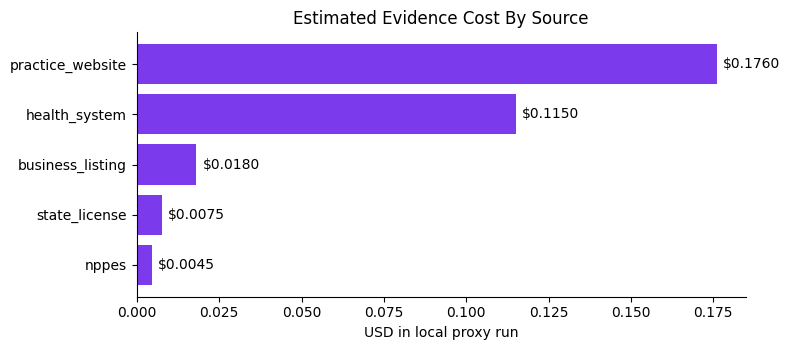

In [19]:
cost_df = pd.DataFrame(cost_rows).sort_values('estimated_cost_usd', ascending=True)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(cost_df['source'], cost_df['estimated_cost_usd'], color='#7c3aed')
ax.set_title('Estimated Evidence Cost By Source')
ax.set_xlabel('USD in local proxy run')
for i, row in cost_df.reset_index(drop=True).iterrows():
    ax.text(row['estimated_cost_usd'] + 0.002, i, f"${row['estimated_cost_usd']:.4f}", va='center')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## 10. Audit Trail And Safe Auto-Update Rules

Every candidate must be explainable: old value, proposed value, source set, URL, confidence, decision, and reason. The production system writes immutable audit events and rollback plans before updating the directory.

In [20]:
audit_path = ROOT / 'submissions/exp0172/audit_events.jsonl'
if audit_path.exists():
    audit_preview = [json.loads(line) for line in audit_path.read_text().splitlines()[:5]]
    display(pd.DataFrame(audit_preview))
else:
    print('Audit fixture not found in this checkout.')

,confidence,created_at,decision,event_id,event_type,evidence_hash,evidence_urls,field,freshness_status,new_value,old_value,pipeline_version,practice_id,provider_id,review_priority_score,review_reason_code,rollback_status,schema_version,sources
0,0.99,2026-06-16T00:00:00+00:00,review,exp0059-00001-aaa7f4008af9cdc7,candidate_update_created,f1e152b652f46295,"[https://example.org/health_system/P0001, https://example.org/practice_website/P0001]",specialty,partially_stale,orthopedics,cardiology,best_cfg_full_peer_context_2026_06_16,PR000,P0001,0.348,insufficient_auto_sources,not_applied_yet,provider-directory-audit-v1,"[health_system, practice_website]"
1,0.99,2026-06-16T00:00:00+00:00,review,exp0059-00002-8fad7ae653956f75,candidate_update_created,ddaf042194dabe91,"[https://example.org/health_system/P0006, https://example.org/nppes/P0006, https://example.org/practice_website/P0006]",phone,partially_stale,555-106-2222,555-207-5959,best_cfg_full_peer_context_2026_06_16,PR002,P0006,0.460,practice_peer_mismatch,not_applied_yet,provider-directory-audit-v1,"[health_system, nppes, practice_website]"
2,0.99,2026-06-16T00:00:00+00:00,auto_apply,exp0059-00003-cc9967e17bda9e5b,candidate_update_created,85f875c68bb32f59,[https://example.org/license/P0011],license_status,fresh,active,inactive,best_cfg_full_peer_context_2026_06_16,PR003,P0011,0.432,auto_apply_criteria_met,eligible,provider-directory-audit-v1,[state_license]
3,0.99,2026-06-16T00:00:00+00:00,review,exp0059-00004-bed76cb5b3e03e6b,candidate_update_created,080c2f10890357fa,"[https://example.org/health_system/P0016, https://example.org/nppes/P0016]",accepting_new_patients,partially_stale,false,true,best_cfg_full_peer_context_2026_06_16,PR005,P0016,0.468,insufficient_auto_sources,not_applied_yet,provider-directory-audit-v1,"[health_system, nppes]"
4,0.99,2026-06-16T00:00:00+00:00,review,exp0059-00005-1bf100c7526a43e6,candidate_update_created,8aa71b4c6b4c5f15,"[https://example.org/health_system/P0031, https://example.org/nppes/P0031, https://example.org/practice_website/P0031]",address,all_stale,317 oak avenue suite 8 florida,"828 Cedar Rd, Suite 9, FL",best_cfg_full_peer_context_2026_06_16,PR010,P0031,0.556,practice_peer_mismatch,not_applied_yet,provider-directory-audit-v1,"[health_system, nppes, practice_website]"


## 11. Technical Architecture Diagram

```mermaid
flowchart TD
    A[HealthLynked Provider and Practice Directory] --> B[Risk Scanner]
    B --> C{Refresh Needed?}
    C -->|No| N[No Change / Confirm Current Record]
    C -->|Yes| D[Trusted Source Connector Orchestrator]
    D --> S1[NPPES / NPI Registry]
    D --> S2[State Licensing Boards]
    D --> S3[CMS / Public Datasets]
    D --> S4[Practice Websites]
    D --> S5[Health System Directories]
    D --> S6[Guarded Business Listing Fallback]
    S1 --> E[Evidence Store]
    S2 --> E
    S3 --> E
    S4 --> E
    S5 --> E
    S6 --> E
    E --> F[Clean and Normalize Data]
    F --> G[Provider / Practice Matching]
    G --> H[Validation Logic]
    H --> I[Confidence Score]
    I --> J{Decision}
    J -->|Record confirmed| N
    J -->|High-confidence update| K[Safe Auto Update]
    J -->|Low confidence or conflict| L[Human Review]
    K --> M[Audit Log + Rollback Plan]
    L --> M
    N --> M
    M --> O[Update Directory + Feedback Loop]
    O --> B
    P[Amazon Bedrock LLM Fallback] -. gated only .-> F
    D -. messy approved page .-> P
```

## 12. AWS Production Plan

| Layer | AWS-oriented implementation |
|---|---|
| Scheduling | EventBridge scheduled refreshes |
| Orchestration | Step Functions state machines |
| Source workers | Lambda for light connectors, ECS/Fargate or AWS Batch for crawlers/bulk jobs |
| Storage | S3 raw evidence snapshots, RDS/DynamoDB normalized evidence and workflow state |
| LLM fallback | Amazon Bedrock behind source/field/failure gates |
| Review queue | Dashboard backed by RDS/DynamoDB and SQS-style work queues |
| Monitoring | CloudWatch metrics/alarms for freshness, cost drift, review backlog, false positives |
| Audit | Append-only audit events, evidence hashes, rollback plan before mutation |

This is intentionally implementable by a lean team: deterministic MVP first, then source hardening, review dashboard, audit/rollback, and production AWS scheduling.

## 13. Bonus Point Coverage

| Bonus item | Coverage |
|---|---|
| Working prototype | This notebook plus `scripts/run_best_pipeline.py` |
| Agent workflow diagram | `ARCHITECTURE_DIAGRAM.md`, `AGENT_WORKFLOW_DIAGRAM.md` |
| Cost estimate per 1,000 records | `COST_MODEL.md`, `cost_model_per_1000.csv` |
| Confidence scoring formula | This notebook, `FIELD_RISK_POLICY.md`, candidate confidence fields |
| Human review dashboard | `dashboard/index.html`, `dashboard_v2/index.html` |
| Duplicate detection | `DUPLICATE_MOVEMENT_DETECTION.md`, duplicate candidate outputs |
| Address normalization | `normalize_address`, `FIELD_RISK_POLICY.md` |
| NPI validation | `NPPES_API_SMOKE.md`, NPPES evidence artifacts |
| Practice-location matching | movement/practice diagnostics and affiliation artifacts |
| Provider movement detection | `provider_movement_candidates.csv` |
| Inactive provider detection | `INACTIVE_PROVIDER_DETECTION.md` |
| Change history and audit log | `audit_events.jsonl`, `provider_change_timeline.csv` |
| Safe auto-update rules | `auto_apply_updates.csv`, field thresholds |
| Clear roadmap | `PRODUCTION_READINESS_SCORECARD.md`, `AWS_PRODUCTION_ARCHITECTURE.md` |

## Final Takeaway

The strongest submission is not the one that blindly changes the most records. It is the one HealthLynked can trust in production.

This MVP finds real candidate changes, explains each recommendation, protects risky updates with human review, keeps auto-apply conservative, tracks cost, and shows a practical AWS path for scaling to thousands or millions of records.